# 基于 WT-LightGBM 的用户侧日前出清Price预测系统（单 Notebook 完整版）

本 Notebook 包含项目的全部 Python 代码，无需依赖 `src/` 目录即可直接运行。

运行顺序：自上而下依次执行每个 Cell 即可。

## 1. 依赖导入

In [1]:
import warnings
import sys
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from datetime import datetime
from enum import Enum
from pathlib import Path
from typing import Any, Dict, Optional

import joblib
import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
import yaml
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore")

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("Python version:", sys.version)

Python version: 3.13.0 (tags/v3.13.0:60403a5, Oct  7 2024, 09:38:07) [MSC v.1941 64 bit (AMD64)]


## 2. 配置定义

In [2]:
# 主配置：与 config/default.yaml 等价，可直接修改
CONFIG = {
    "data": {
        "granularity": "15min",
        "reader_type": "dataset_csv",
        "dataset_root": "./Dataset",
        "sources": {
            "target_price": "用户侧日前出清发布/用户侧日前出清发布_统一结算点Price最终结果.csv",
            "sys_load_pred": "短期系统负荷预测/短期系统负荷预测信息_出清发布电力.csv",
            "wind_power_pred": "统调风电功率预测/统调风电功率预测_风力_地区汇总_出清发布电力.csv",
            "solar_power_pred": "统调光电功率预测/统调光电功率预测_太阳能_地区汇总_出清发布电力.csv",
            "power_import_plan": "受电计划/受电计划_华东_出清发布电力.csv",
            "coal_gen_plan": "煤电发电计划/煤电发电计划_地区汇总_终发布电力.csv",
            "gas_gen_plan": "燃机固定出力总值/燃机固定出力总值_地区汇总_出清发布电力.csv",
            "storage_plan": "储能发电计划/储能发电计划_地区汇总_终发布电力.csv",
            "reserve_pos": "正负备用空间/正负备用空间_正备用.csv",
            "reserve_neg": "正负备用空间/正负备用空间_负备用.csv",
            "actual_sys_load": "实际系统负荷/实际系统负荷_实际发布电力.csv",
            "actual_wind": "实际统调风光情况/实际统调风光情况_风力_地区汇总_实际发布电力.csv",
            "actual_solar": "实际统调风光情况/实际统调风光情况_光伏_地区汇总_实际发布电力.csv",
            "renewable_capacity": "分省可再生能源发电能力预测_发电能力.csv",
        }
    },
    "preprocessing": {
        "missing_strategy": "ffill",
        "outlier_method": "iqr",
        "outlier_threshold": 3.0,
        "normalize_method": "none",
        "fill_00_with_24": True,
        "solar_wind_night_fill": 0.0
    },
    "features": {
        "lag_windows": [1, 7],
        "rolling_windows": [96, 672],
        "use_price_lags": True,
        "use_actual_lags": True,
        "use_date_features": True
    },
    "model": {
        "type": "wtlgbm",
        "wavelet": "db4",
        "decompose_level": 2,
        "window_size": 30,
        "train": {
            "test_days": 30,
            "early_stopping_rounds": 50,
            "num_boost_round": 5000,
            "cross_validation": True,
            "cv_folds": 5
        },
        "predict": {
            "horizon": 96
        },
        "lgbm_params": {
            "learning_rate": 0.05,
            "num_leaves": 63,
            "max_depth": 12,
            "min_data_in_leaf": 20,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "lambda_l1": 0.01,
            "lambda_l2": 0.01
        },

        # 样本加权策略：none | price_level | spike | quantile | combined
        "weight_method": "combined",
        "weight_spike_sigma": 2.0,
        "weight_high_price_percentile": 80.0
    },
    "evaluation": {
        "spike_threshold_sigma": 2.0,
        "alert_thresholds": {
            "mape": 20,
            "direction_accuracy": 55
        }
    },
    "output": {
        "prediction_dir": "./data/predictions/",
        "report_dir": "./reports/",
        "model_dir": "./models/",
        "feature_store_dir": "./data/features/",
        "log_dir": "./logs/",
        "log_level": "INFO"
    },
    "calendar": {
        "use_chinese_calendar": True
    }
}

# 输出目录创建
for key in ["prediction_dir", "report_dir", "model_dir", "feature_store_dir", "log_dir"]:
    Path(CONFIG["output"][key]).mkdir(parents=True, exist_ok=True)

print("配置加载完成，模型类型:", CONFIG["model"]["type"])


配置加载完成，模型类型: wtlgbm


## 3. Schema / 数据结构定义

In [3]:
class Granularity(Enum):
    MIN15 = 15
    HOUR1 = 60


@dataclass
class ValidationReport:
    table_name: str
    total_rows: int
    total_points: int
    missing_rate: float
    outlier_count: int
    time_continuity: dict
    duplicate_dates: int
    granularity: Granularity
    is_passed: bool
    warnings: list = field(default_factory=list)

    def __repr__(self):
        return (
            f"ValidationReport(table_name={self.table_name}, total_points={self.total_points}, "
            f"missing_rate={self.missing_rate:.2%}, outlier_count={self.outlier_count}, "
            f"duplicate_dates={self.duplicate_dates}, is_passed={self.is_passed})"
        )

## 4. Time工具

In [4]:
class TimeUtils:
    """时序数据处理工具类。"""
    POINTS_PER_DAY = 96

    @staticmethod
    def classify_period(timestamps: pd.DatetimeIndex) -> np.ndarray:
        hour = timestamps.hour
        is_peak = ((hour >= 8) & (hour < 11)) | ((hour >= 17) & (hour < 21))
        is_valley = (hour >= 0) & (hour < 6)
        return np.where(is_valley, 0, np.where(is_peak, 2, 1))

    @staticmethod
    def is_holiday(timestamps: pd.DatetimeIndex, use_chinese_calendar: bool = True) -> np.ndarray:
        if use_chinese_calendar:
            try:
                import chinese_calendar
                return np.array([int(chinese_calendar.is_holiday(ts)) for ts in timestamps])
            except ImportError:
                pass
        return (timestamps.weekday >= 5).astype(int)

    @staticmethod
    def get_date_features(timestamps, use_chinese_calendar: bool = True) -> pd.DataFrame:
        timestamps = pd.to_datetime(timestamps)
        if not isinstance(timestamps, pd.DatetimeIndex):
            timestamps = pd.DatetimeIndex(timestamps)
        features = pd.DataFrame(index=timestamps)
        features["hour"] = timestamps.hour
        features["minute"] = timestamps.minute
        features["weekday"] = timestamps.weekday
        features["month"] = timestamps.month
        features["day_of_year"] = timestamps.dayofyear
        features["is_weekend"] = (timestamps.weekday >= 5).astype(int)
        features["is_holiday"] = TimeUtils.is_holiday(timestamps, use_chinese_calendar)
        hour = timestamps.hour
        features["is_peak"] = (((hour >= 8) & (hour < 11)) | ((hour >= 17) & (hour < 21))).astype(int)
        features["hour_sin"] = np.sin(2 * np.pi * timestamps.hour / 24)
        features["hour_cos"] = np.cos(2 * np.pi * timestamps.hour / 24)
        features["period_type"] = TimeUtils.classify_period(timestamps)
        return features

    @staticmethod
    def get_points_per_day(freq: str = "15min") -> int:
        mapping = {"15min": 96, "1h": 24, "30min": 48, "5min": 288}
        return mapping.get(freq, 96)

print("TimeUtils 定义完成")

TimeUtils 定义完成


## 5. 数据读取器

In [5]:
class DatasetCSVReader:
    """Dataset/ 目录 CSV 读取器：处理宽表格式（96 时点）。"""

    META_COLS = [
        "ID", "父ID", "数据类型", "数据地区", "数据所属菜单",
        "数据来源", "数据描述", "日期", "更新Time",
    ]

    def __init__(self, dataset_root: str, data_sources: dict):
        self.dataset_root = Path(dataset_root)
        self.data_sources = data_sources

    def read_table(
        self,
        table_name: str,
        start_date: Optional[str] = None,
        end_date: Optional[str] = None,
        fill_00_with_24: bool = True,
    ) -> pd.DataFrame:
        if table_name not in self.data_sources:
            raise KeyError(f"表 '{table_name}' 未在 data_sources 中配置")
        path = self.dataset_root / self.data_sources[table_name]
        if not path.exists():
            raise FileNotFoundError(f"数据文件不存在: {path}")

        df = pd.read_csv(path, parse_dates=["日期"])
        df = df.drop_duplicates(subset=["日期"], keep="last")

        time_cols = [c for c in df.columns if c not in self.META_COLS]
        df_long = df.melt(
            id_vars=["日期"], value_vars=time_cols,
            var_name="time_str", value_name="value"
        )
        df_long["base_date"] = df_long["日期"].dt.strftime("%Y-%m-%d")
        next_day_mask = df_long["time_str"] == "24:00"
        df_long.loc[next_day_mask, "time_str"] = "00:00"
        df_long.loc[next_day_mask, "base_date"] = (
            pd.to_datetime(df_long.loc[next_day_mask, "base_date"]) + pd.Timedelta(days=1)
        ).dt.strftime("%Y-%m-%d")
        df_long["timestamp"] = pd.to_datetime(df_long["base_date"] + " " + df_long["time_str"])
        df_long = df_long[["timestamp", "value"]].sort_values("timestamp").reset_index(drop=True)
        df_long["field_name"] = table_name

        df_long = df_long.sort_values("value", na_position="last")
        df_long = df_long.drop_duplicates(subset=["timestamp"], keep="last")
        df_long = df_long.sort_values("timestamp").reset_index(drop=True)

        if start_date is not None:
            df_long = df_long[df_long["timestamp"] >= pd.to_datetime(start_date)]
        if end_date is not None:
            df_long = df_long[df_long["timestamp"] <= pd.to_datetime(end_date)]
        return df_long

    def read_target(self, start_date: Optional[str] = None, end_date: Optional[str] = None) -> pd.DataFrame:
        return self.read_table("target_price", start_date, end_date)

    def list_available_tables(self) -> list:
        return list(self.data_sources.keys())

    def get_date_range(self, table_name: str) -> tuple:
        df = self.read_table(table_name)
        return df["timestamp"].min(), df["timestamp"].max()

print("DatasetCSVReader 定义完成")

DatasetCSVReader 定义完成


## 6. 数据校验器

In [6]:
class DataValidator:
    """数据质量校验器"""

    def __init__(self, expected_points_per_day: int = 96):
        self.expected_points_per_day = expected_points_per_day

    def check_completeness(self, df: pd.DataFrame) -> float:
        return df["value"].isna().mean()

    def check_outliers(self, df: pd.DataFrame, method: str = "iqr", threshold: float = 3.0) -> int:
        values = df["value"].dropna()
        if values.empty:
            return 0
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - threshold * iqr
        upper = q3 + threshold * iqr
        return int(((values < lower) | (values > upper)).sum())

    def check_time_continuity(self, df: pd.DataFrame) -> dict:
        ts = pd.to_datetime(df["timestamp"]).sort_values()
        if len(ts) < 2:
            return {"missing_periods": 0, "expected_periods": len(ts)}
        freq = pd.Timedelta(minutes=15)
        full_range = pd.date_range(ts.min(), ts.max(), freq=freq)
        missing = len(full_range) - len(ts)
        return {"missing_periods": missing, "expected_periods": len(full_range)}

    def check_duplicate_dates(self, df: pd.DataFrame) -> int:
        ts = pd.to_datetime(df["timestamp"])
        return int(ts.duplicated().sum())

    def validate(self, table_name: str, df: pd.DataFrame, missing_threshold: float = 0.5) -> ValidationReport:
        missing_rate = self.check_completeness(df)
        outliers = self.check_outliers(df)
        continuity = self.check_time_continuity(df)
        duplicates = self.check_duplicate_dates(df)
        warnings = []
        if missing_rate > missing_threshold:
            warnings.append(f"缺失率 {missing_rate:.2%} 超过阈值 {missing_threshold:.2%}")
        if continuity["missing_periods"] > 0:
            warnings.append(f"缺失 {continuity['missing_periods']} 个时点")
        if duplicates > 0:
            warnings.append(f"存在 {duplicates} 个重复日期")
        is_passed = len(warnings) == 0
        return ValidationReport(
            table_name=table_name,
            total_rows=len(df) // self.expected_points_per_day if self.expected_points_per_day else len(df),
            total_points=len(df),
            missing_rate=missing_rate,
            outlier_count=outliers,
            time_continuity=continuity,
            duplicate_dates=duplicates,
            granularity=Granularity.MIN15,
            is_passed=is_passed,
            warnings=warnings
        )

print("DataValidator 定义完成")

DataValidator 定义完成


## 7. 数据适配器

In [7]:
class DataAdapter:
    """将多个长表数据合并为按Time戳对齐的宽表。"""

    def __init__(self, fill_00_with_24: bool = True, solar_wind_night_fill: Optional[float] = 0.0):
        self.fill_00_with_24 = fill_00_with_24
        self.solar_wind_night_fill = solar_wind_night_fill

    def merge_tables(self, tables: Dict[str, pd.DataFrame], target_df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
        merged = None
        for name, df in tables.items():
            df = df[["timestamp", "value"]].copy()
            df.rename(columns={"value": name}, inplace=True)
            if merged is None:
                merged = df
            else:
                merged = pd.merge(merged, df, on="timestamp", how="outer")
        if target_df is not None:
            target = target_df[["timestamp", "value"]].copy()
            target.rename(columns={"value": "target"}, inplace=True)
            merged = pd.merge(merged, target, on="timestamp", how="outer")
        merged = merged.sort_values("timestamp").reset_index(drop=True)
        return merged

    def handle_missing(self, df: pd.DataFrame, strategy: str = "ffill", solar_wind_cols: Optional[list] = None) -> pd.DataFrame:
        df = df.copy()
        if solar_wind_cols and self.solar_wind_night_fill is not None:
            for col in solar_wind_cols:
                if col in df.columns:
                    df[col] = df[col].fillna(self.solar_wind_night_fill)
        if strategy == "ffill":
            df = df.ffill().bfill()
        elif strategy == "linear":
            df = df.interpolate(method="linear").ffill().bfill()
        elif strategy == "mean":
            df = df.fillna(df.mean(numeric_only=True))
        return df

    def align_to_target(self, df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
        return df[df[target_col].notna()].copy()

    def build_panel(
        self, tables: Dict[str, pd.DataFrame], target_df: pd.DataFrame,
        align_to_target: bool = True, **kwargs
    ) -> pd.DataFrame:
        solar_wind_cols = kwargs.get("solar_wind_cols", ["wind_power_pred", "solar_power_pred"])
        missing_strategy = kwargs.get("missing_strategy", "ffill")
        df = self.merge_tables(tables, target_df)
        df = self.handle_missing(df, strategy=missing_strategy, solar_wind_cols=solar_wind_cols)
        if align_to_target:
            df = self.align_to_target(df)
        return df

print("DataAdapter 定义完成")

DataAdapter 定义完成


## 8. 预处理器

In [8]:
class Preprocessor:
    """数据预处理器"""

    def __init__(self, config: dict):
        self.missing_strategy = config.get("missing_strategy", "ffill")
        self.outlier_method = config.get("outlier_method", "iqr")
        self.outlier_threshold = config.get("outlier_threshold", 3.0)
        self.normalize_method = config.get("normalize_method", "standard")
        self.scaler = None
        self.target_scaler = None

    def handle_missing(self, df: pd.DataFrame, solar_wind_cols: Optional[list] = None) -> pd.DataFrame:
        df = df.copy()
        if solar_wind_cols:
            for col in solar_wind_cols:
                if col in df.columns:
                    df[col] = df[col].fillna(0)
        if self.missing_strategy == "ffill":
            df = df.ffill().bfill()
        elif self.missing_strategy == "linear":
            df = df.interpolate(method="linear").ffill().bfill()
        elif self.missing_strategy == "mean":
            df = df.fillna(df.mean(numeric_only=True))
        return df

    def handle_outliers(self, df: pd.DataFrame, exclude_cols: Optional[list] = None) -> pd.DataFrame:
        df = df.copy()
        exclude = set(exclude_cols or ["target"])
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col in exclude:
                continue
            values = df[col].dropna()
            if values.empty:
                continue
            q1, q3 = values.quantile([0.25, 0.75])
            iqr = q3 - q1
            lower = q1 - self.outlier_threshold * iqr
            upper = q3 + self.outlier_threshold * iqr
            df[col] = df[col].clip(lower, upper)
        return df

    def normalize(self, df: pd.DataFrame, feature_cols: list, fit: bool = True) -> pd.DataFrame:
        df = df.copy()
        if self.normalize_method == "none":
            return df
        cols = [c for c in feature_cols if c in df.columns]
        if fit:
            if self.normalize_method == "standard":
                self.scaler = StandardScaler()
            elif self.normalize_method == "minmax":
                self.scaler = MinMaxScaler()
            df[cols] = self.scaler.fit_transform(df[cols])
        else:
            if self.scaler is None:
                raise RuntimeError("Scaler 未训练，无法做 transform")
            df[cols] = self.scaler.transform(df[cols])
        return df

print("Preprocessor 定义完成")

Preprocessor 定义完成


## 9. 特征注册中心

In [9]:
@dataclass
class FeatureMeta:
    name: str
    category: str
    status: str
    description: str = ""
    source_table: Optional[str] = None
    formula: Optional[str] = None
    dtype: str = "float"
    importance: float = 0.0
    version: int = 1


class FeatureRegistry:
    """特征注册中心"""

    VALID_STATUSES = {"OK", "PENDING", "DROPPED"}
    VALID_CATEGORIES = {"direct", "constructed", "lag", "date"}

    def __init__(self):
        self.features: dict[str, FeatureMeta] = {}

    def register(self, meta: FeatureMeta) -> None:
        if meta.status not in self.VALID_STATUSES:
            raise ValueError(f"Invalid status: {meta.status}")
        if meta.category not in self.VALID_CATEGORIES:
            raise ValueError(f"Invalid category: {meta.category}")
        self.features[meta.name] = meta

    def get_available_features(self) -> list[str]:
        return [name for name, meta in self.features.items() if meta.status == "OK"]

    @classmethod
    def from_config(cls, config: dict) -> "FeatureRegistry":
        registry = cls()
        for item in config.get("features", []):
            meta = FeatureMeta(
                name=item["name"],
                category=item["category"],
                status=item.get("status", "OK"),
                description=item.get("description", ""),
                source_table=item.get("source_table"),
                formula=item.get("formula"),
                dtype=item.get("dtype", "float"),
            )
            registry.register(meta)
        return registry

print("FeatureRegistry 定义完成")

FeatureRegistry 定义完成


## 10. 特征构建器

In [10]:
class FeatureBuilder:
    """特征构建器：将原始数据转换为模型可用特征矩阵。"""

    DIRECT_FEATURES = [
        "sys_load_pred", "wind_power_pred", "solar_power_pred",
        "power_import_plan", "coal_gen_plan", "gas_gen_plan",
        "storage_plan", "reserve_pos", "reserve_neg", "renewable_capacity"
    ]

    def __init__(
        self,
        lag_windows=None,
        rolling_windows=None,
        use_price_lags=True,
        use_actual_lags=True,
        use_date_features=True,
        registry: Optional[FeatureRegistry] = None,
        use_chinese_calendar: bool = True,
    ):
        self.lag_windows = lag_windows or [1, 7]
        self.rolling_windows = rolling_windows or [96, 672]
        self.use_price_lags = use_price_lags
        self.use_actual_lags = use_actual_lags
        self.use_date_features = use_date_features
        self.registry = registry
        self.use_chinese_calendar = use_chinese_calendar

    def build_all(self, df: pd.DataFrame) -> pd.DataFrame:
        features = df[["timestamp"]].copy()
        features = pd.concat([features, self._build_direct_features(df)], axis=1)
        features = pd.concat([features, self._build_constructed_features(df)], axis=1)
        if self.use_price_lags and "target" in df.columns:
            features = pd.concat([features, self._build_price_lags(df)], axis=1)
        if self.use_actual_lags:
            features = pd.concat([features, self._build_actual_lags(df)], axis=1)
        if self.use_date_features:
            features = pd.concat([features, self._build_date_features(df)], axis=1)
        return features

    def _select_direct_features(self) -> list[str]:
        if self.registry is None:
            return self.DIRECT_FEATURES
        available = set(self.registry.get_available_features())
        return [c for c in self.DIRECT_FEATURES if c in available]

    def _build_direct_features(self, df: pd.DataFrame) -> pd.DataFrame:
        cols = [c for c in self._select_direct_features() if c in df.columns]
        return df[cols].copy()

    def _build_constructed_features(self, df: pd.DataFrame) -> pd.DataFrame:
        constructed = pd.DataFrame(index=df.index)
        available = set(self.registry.get_available_features()) if self.registry else None

        def _enabled(name: str) -> bool:
            return available is None or name in available

        required = ["sys_load_pred", "power_import_plan", "coal_gen_plan",
                    "gas_gen_plan", "storage_plan", "wind_power_pred", "solar_power_pred"]
        if all(c in df.columns for c in required):
            if _enabled("bidding_space"):
                constructed["bidding_space"] = (
                    df["sys_load_pred"] + df["power_import_plan"]
                    - df["coal_gen_plan"] - df["gas_gen_plan"] - df["storage_plan"]
                    - df["wind_power_pred"] - df["solar_power_pred"]
                )
            if _enabled("net_load"):
                constructed["net_load"] = df["sys_load_pred"] - df["wind_power_pred"] - df["solar_power_pred"]
            if _enabled("import_ratio"):
                constructed["import_ratio"] = df["power_import_plan"] / df["sys_load_pred"]
            if _enabled("renewable_penetration"):
                constructed["renewable_penetration"] = (
                    df["wind_power_pred"] + df["solar_power_pred"]
                ) / df["sys_load_pred"]
            if _enabled("thermal_ratio"):
                constructed["thermal_ratio"] = (
                    df["coal_gen_plan"] + df["gas_gen_plan"]
                ) / df["sys_load_pred"]
        if "reserve_pos" in df.columns and "sys_load_pred" in df.columns and _enabled("reserve_margin"):
            constructed["reserve_margin"] = df["reserve_pos"] / df["sys_load_pred"]
        if "reserve_neg" in df.columns and "sys_load_pred" in df.columns and _enabled("negative_reserve_margin"):
            constructed["negative_reserve_margin"] = df["reserve_neg"] / df["sys_load_pred"]
        if all(c in df.columns for c in ["reserve_pos", "reserve_neg", "sys_load_pred"]) and _enabled("total_reserve_margin"):
            constructed["total_reserve_margin"] = (df["reserve_pos"] + df["reserve_neg"]) / df["sys_load_pred"]
        if "actual_sys_load_lag_1d" in df.columns and "sys_load_pred" in df.columns and _enabled("load_forecast_error"):
            constructed["load_forecast_error"] = df["actual_sys_load_lag_1d"] - df["sys_load_pred"]

        # 尖峰相关特征
        if all(c in df.columns for c in ["wind_power_pred", "solar_power_pred"]) and _enabled("renewable_volatility"):
            renewable = df["wind_power_pred"] + df["solar_power_pred"]
            constructed["renewable_volatility"] = renewable.diff().abs()
        if "sys_load_pred" in df.columns and _enabled("load_ramp"):
            constructed["load_ramp"] = df["sys_load_pred"].diff().abs()
        if all(c in df.columns for c in ["sys_load_pred", "wind_power_pred", "solar_power_pred"]) and _enabled("net_load_ramp"):
            net_load = df["sys_load_pred"] - df["wind_power_pred"] - df["solar_power_pred"]
            constructed["net_load_ramp"] = net_load.diff().abs()
        if "sys_load_pred" in df.columns and _enabled("load_ratio_to_max"):
            constructed["load_ratio_to_max"] = df["sys_load_pred"] / df["sys_load_pred"].rolling(window=672, min_periods=1).max()
        return constructed

    def _build_price_lags(self, df: pd.DataFrame) -> pd.DataFrame:
        """构建Price滞后特征"""
        lags = pd.DataFrame(index=df.index)
        points_per_day = TimeUtils.get_points_per_day("15min")
        for d in self.lag_windows:
            lags[f"user_price_lag_{d}d"] = df["target"].shift(d * points_per_day)
        for w in self.rolling_windows:
            lags[f"user_price_ma_{w}"] = df["target"].shift(1).rolling(window=w, min_periods=1).mean()
            lags[f"user_price_std_{w}"] = df["target"].shift(1).rolling(window=w, min_periods=1).std()
            lags[f"user_price_max_{w}"] = df["target"].shift(1).rolling(window=w, min_periods=1).max()
            lags[f"user_price_min_{w}"] = df["target"].shift(1).rolling(window=w, min_periods=1).min()
        return lags

    def _build_actual_lags(self, df: pd.DataFrame) -> pd.DataFrame:
        """构建实际值滞后特征"""
        lags = pd.DataFrame(index=df.index)
        points_per_day = TimeUtils.get_points_per_day("15min")
        if "actual_sys_load" in df.columns:
            lags["actual_sys_load_lag_1d"] = df["actual_sys_load"].shift(points_per_day)
        if "actual_wind_solar" in df.columns:
            lags["actual_wind_solar_lag_1d"] = df["actual_wind_solar"].shift(points_per_day)
        return lags

    def _build_date_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """日期特征编码"""
        timestamps = pd.to_datetime(df["timestamp"])
        features = TimeUtils.get_date_features(timestamps, self.use_chinese_calendar)
        features.index = df.index
        return features

print("FeatureBuilder 定义完成")


FeatureBuilder 定义完成


## 11. 特征存储（简化版）

In [11]:
class FeatureStore:
    """特征存储：保存特征矩阵为 Parquet + JSON 元数据。"""

    def __init__(self, store_dir: str = "./data/features"):
        self.store_dir = Path(store_dir)
        self.store_dir.mkdir(parents=True, exist_ok=True)

    def save(self, features: pd.DataFrame, feature_names: list, target_col: str,
             version: str, metadata: Optional[dict] = None) -> dict:
        version_dir = self.store_dir / version
        version_dir.mkdir(parents=True, exist_ok=True)
        parquet_path = version_dir / "features.parquet"
        meta_path = version_dir / "meta.json"
        features.to_parquet(parquet_path, index=False)
        meta = {
            "version": version,
            "n_samples": len(features),
            "n_features": len(feature_names),
            "feature_names": feature_names,
            "target_col": target_col,
            "metadata": metadata or {}
        }
        import json
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump(meta, f, ensure_ascii=False, indent=2)
        return {"parquet": str(parquet_path), "meta": str(meta_path)}

print("FeatureStore 定义完成")

FeatureStore 定义完成


## 12. 评估指标

In [12]:
class MetricsCalculator:
    """评估指标计算器"""

    @staticmethod
    def mae(y_true, y_pred) -> float:
        return float(np.mean(np.abs(y_true - y_pred)))

    @staticmethod
    def rmse(y_true, y_pred) -> float:
        return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

    @staticmethod
    def mape(y_true, y_pred, epsilon: float = 1e-8) -> float:
        mask = np.abs(y_true) > epsilon
        return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + epsilon))) * 100)

    @staticmethod
    def smape(y_true, y_pred) -> float:
        return float(np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100)

    @staticmethod
    def r2(y_true, y_pred) -> float:
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        if ss_tot == 0:
            return 0.0
        return float(1 - ss_res / ss_tot)

    @staticmethod
    def direction_accuracy(y_true, y_pred) -> float:
        actual_dir = np.sign(np.diff(y_true))
        pred_dir = np.sign(np.diff(y_pred))
        return float(np.mean(actual_dir == pred_dir) * 100)

    @staticmethod
    def spike_capture_rate(y_true, y_pred, threshold_sigma: float = 2.0) -> dict:
        threshold = np.mean(y_true) + threshold_sigma * np.std(y_true)
        true_spikes = y_true > threshold
        pred_spikes = y_pred > threshold
        tp = np.sum(true_spikes & pred_spikes)
        fp = np.sum(~true_spikes & pred_spikes)
        fn = np.sum(true_spikes & ~pred_spikes)
        return {
            "spike_capture_rate": tp / (tp + fn) if (tp + fn) > 0 else 1.0,
            "spike_false_alarm": fp / (fp + tp) if (fp + tp) > 0 else 0.0,
            "spike_miss_rate": fn / (tp + fn) if (tp + fn) > 0 else 0.0
        }

    @staticmethod
    def period_mape(y_true, y_pred, periods) -> dict:
        results = {}
        for period_name in np.unique(periods):
            mask = periods == period_name
            results[str(period_name)] = MetricsCalculator.mape(y_true[mask], y_pred[mask])
        return results

    def compute_all(self, y_true, y_pred, periods=None) -> dict:
        result = {
            "MAE": self.mae(y_true, y_pred),
            "RMSE": self.rmse(y_true, y_pred),
            "MAPE": self.mape(y_true, y_pred),
            "sMAPE": self.smape(y_true, y_pred),
            "R2": self.r2(y_true, y_pred),
            "direction_accuracy": self.direction_accuracy(y_true, y_pred),
            "spike_metrics": self.spike_capture_rate(y_true, y_pred)
        }
        if periods is not None:
            result["period_mape"] = self.period_mape(y_true, y_pred, periods)
        return result

print("MetricsCalculator 定义完成")

MetricsCalculator 定义完成


## 13. 报告生成器

In [13]:
class ReportGenerator:
    """报告生成器"""

    def __init__(self, report_dir: str = "./reports"):
        self.report_dir = Path(report_dir)
        self.report_dir.mkdir(parents=True, exist_ok=True)

    def plot_prediction_vs_actual(
        self, y_true: np.ndarray, y_pred: np.ndarray,
        timestamps: np.ndarray, save_path: str
    ) -> None:
        matplotlib.use("Agg")
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        ts = pd.to_datetime(timestamps)
        axes[0].plot(ts, y_true, label="Actual", linewidth=1.5)
        axes[0].plot(ts, y_pred, label="Predicted", linewidth=1.5, alpha=0.8)
        axes[0].set_title("Prediction vs Actual")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(ts, y_true - y_pred, color="gray", linewidth=1)
        axes[1].axhline(0, color="red", linestyle="--")
        axes[1].set_title("Residual (Actual - Predicted)")
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        plt.close(fig)

    def generate_daily(
        self, date: str, y_true: np.ndarray, y_pred: np.ndarray,
        timestamps: np.ndarray, importance: Optional[pd.DataFrame] = None,
        save_plot: bool = True
    ) -> dict:
        calc = MetricsCalculator()
        periods = TimeUtils.classify_period(pd.to_datetime(timestamps)) if len(timestamps) > 0 else None
        metrics = calc.compute_all(y_true, y_pred, periods=periods)
        report = {"date": date, "metrics": metrics, "n_samples": len(y_true)}
        if save_plot:
            save_path = self.report_dir / "daily" / f"{date}.png"
            save_path.parent.mkdir(parents=True, exist_ok=True)
            self.plot_prediction_vs_actual(y_true, y_pred, timestamps, str(save_path))
            report["plot_path"] = str(save_path)
        return report

print("ReportGenerator 定义完成")

ReportGenerator 定义完成


## 14. 小波分解模块

In [14]:
class WaveletDecomposer:
    """小波分解/重构：WT-LGBM 核心前置模块"""

    def __init__(self, wavelet: str = "db4", level: int = 2):
        self.wavelet = wavelet
        self.level = level

    def stationary_decompose(self, signal: np.ndarray) -> dict:
        signal = np.asarray(signal)
        orig_len = len(signal)
        pad_len = (2 ** self.level) - (orig_len % (2 ** self.level))
        if pad_len == 2 ** self.level:
            pad_len = 0
        if pad_len > 0:
            signal = np.pad(signal, (0, pad_len), mode="edge")
        coeffs = pywt.swt(signal, self.wavelet, level=self.level, trim_approx=True)
        result = {"low": coeffs[0][:orig_len]}
        for i in range(1, self.level + 1):
            result[f"high_{i}"] = coeffs[i][:orig_len]
        return result

    def stationary_reconstruct(self, components: dict) -> np.ndarray:
        coeffs = [components["low"]]
        for i in range(1, self.level + 1):
            coeffs.append(components[f"high_{i}"])
        return pywt.iswt(coeffs, self.wavelet)

print("WaveletDecomposer 定义完成")

WaveletDecomposer 定义完成


## 15. LightGBM 训练器

In [15]:
class LGBMTrainer:
    """LightGBM 训练器"""

    def __init__(self, params: dict, component_name: str):
        self.params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "learning_rate": params.get("learning_rate", 0.05),
            "num_leaves": params.get("num_leaves", 63),
            "max_depth": params.get("max_depth", 12),
            "min_data_in_leaf": params.get("min_data_in_leaf", 20),
            "feature_fraction": params.get("feature_fraction", 0.8),
            "bagging_fraction": params.get("bagging_fraction", 0.8),
            "bagging_freq": params.get("bagging_freq", 5),
            "lambda_l1": params.get("lambda_l1", 0.01),
            "lambda_l2": params.get("lambda_l2", 0.01),
            "verbosity": -1
        }
        self.component_name = component_name
        self.model = None
        self.feature_names = None

    def _compute_weights(self, y: np.ndarray, method: str = "none", spike_sigma: float = 2.0,
                         high_price_percentile: float = 80.0) -> np.ndarray:
        """根据目标值计算样本权重，用于提升高价/尖峰拟合。"""
        if method == "none" or method is None:
            return np.ones_like(y, dtype=float)
        if method == "price_level":
            threshold = np.percentile(y, high_price_percentile)
            weights = np.where(y >= threshold, 2.0, 1.0)
            return weights
        if method == "spike":
            threshold = np.mean(y) + spike_sigma * np.std(y)
            weights = np.where(y >= threshold, 3.0, 1.0)
            return weights
        if method == "quantile":
            ranks = np.argsort(np.argsort(y))
            quantiles = (ranks + 1) / len(y)
            weights = 1.0 + 2.0 * quantiles
            return weights
        if method == "combined":
            spike_threshold = np.mean(y) + spike_sigma * np.std(y)
            level_threshold = np.percentile(y, high_price_percentile)
            weights = np.where(y >= spike_threshold, 4.0,
                               np.where(y >= level_threshold, 2.0, 1.0))
            return weights
        return np.ones_like(y, dtype=float)

    def train(
        self, X_train, y_train, X_valid, y_valid,
        feature_names: list, early_stopping_rounds: int = 50,
        num_boost_round: int = 5000,
        weight_method: str = "none",
        weight_spike_sigma: float = 2.0,
        weight_high_price_percentile: float = 80.0
    ) -> dict:
        self.feature_names = feature_names
        train_weights = self._compute_weights(
            y_train, method=weight_method,
            spike_sigma=weight_spike_sigma,
            high_price_percentile=weight_high_price_percentile
        )
        train_data = lgb.Dataset(X_train, label=y_train, weight=train_weights, feature_name=feature_names)
        valid_data = lgb.Dataset(X_valid, label=y_valid, feature_name=feature_names, reference=train_data)
        callbacks = [
            lgb.early_stopping(early_stopping_rounds, verbose=False),
            lgb.log_evaluation(period=0)
        ]
        self.model = lgb.train(
            params=self.params, train_set=train_data,
            valid_sets=[valid_data], valid_names=["valid"],
            num_boost_round=num_boost_round, callbacks=callbacks
        )
        return {
            "best_iteration": self.model.best_iteration,
            "best_score": self.model.best_score["valid"]["rmse"]
        }

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise RuntimeError(f"Component '{self.component_name}' not trained")
        return self.model.predict(X, num_iteration=self.model.best_iteration)

    def get_feature_importance(self, importance_type: str = "gain") -> pd.DataFrame:
        importance = self.model.feature_importance(importance_type=importance_type)
        return pd.DataFrame({
            "feature": self.feature_names,
            "importance": importance
        }).sort_values("importance", ascending=False)

print("LGBMTrainer 定义完成")


LGBMTrainer 定义完成


## 16. WT-LightGBM 模型

In [16]:
class WTLGBMModel:
    """小波变换 + LightGBM 模型。"""

    def __init__(self, config: dict):
        self.config = config
        self.wavelet = WaveletDecomposer(
            wavelet=config.get("wavelet", "db4"),
            level=config.get("decompose_level", 2)
        )
        self.lgbm_params = config.get("lgbm_params", {})
        self.early_stopping_rounds = config.get("early_stopping_rounds", 50)
        self.num_boost_round = config.get("num_boost_round", 2000)
        self.weight_method = config.get("weight_method", "none")
        self.weight_spike_sigma = config.get("weight_spike_sigma", 2.0)
        self.weight_high_price_percentile = config.get("weight_high_price_percentile", 80.0)
        self.trainers: dict[str, LGBMTrainer] = {}
        self.feature_names = None

    def fit(self, X_train, y_train, X_valid=None, y_valid=None, feature_names=None):
        if X_valid is None or y_valid is None:
            split_idx = int(len(X_train) * 0.8)
            X_valid, y_valid = X_train[split_idx:], y_train[split_idx:]
            X_train, y_train = X_train[:split_idx], y_train[:split_idx]
        self.feature_names = feature_names or []
        train_components = self.wavelet.stationary_decompose(y_train)
        valid_components = self.wavelet.stationary_decompose(y_valid)
        results = {}
        for key in ["low"] + [f"high_{i}" for i in range(1, self.wavelet.level + 1)]:
            trainer = LGBMTrainer(self.lgbm_params, key)
            results[key] = trainer.train(
                X_train=X_train, y_train=train_components[key],
                X_valid=X_valid, y_valid=valid_components[key],
                feature_names=self.feature_names,
                early_stopping_rounds=self.early_stopping_rounds,
                num_boost_round=self.num_boost_round,
                weight_method=self.weight_method,
                weight_spike_sigma=self.weight_spike_sigma,
                weight_high_price_percentile=self.weight_high_price_percentile
            )
            self.trainers[key] = trainer
        return results

    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self.trainers:
            raise RuntimeError("WT-LGBM 模型未训练")
        components = {}
        for key, trainer in self.trainers.items():
            components[key] = trainer.predict(X)
        return self.wavelet.stationary_reconstruct(components)

    def save(self, path: str) -> None:
        joblib.dump({
            "trainers": self.trainers,
            "config": self.config,
            "feature_names": self.feature_names
        }, path)

    @classmethod
    def load(cls, path: str):
        data = joblib.load(path)
        model = cls(data["config"])
        model.trainers = data["trainers"]
        model.feature_names = data["feature_names"]
        return model

    def get_feature_importance(self, aggregate: str = "mean") -> pd.DataFrame:
        if not self.trainers:
            return None
        importances = []
        for trainer in self.trainers.values():
            imp = trainer.get_feature_importance()
            imp = imp.rename(columns={"importance": trainer.component_name})
            importances.append(imp)
        merged = importances[0]
        for imp in importances[1:]:
            merged = merged.merge(imp, on="feature", how="outer")
        imp_cols = [c for c in merged.columns if c != "feature"]
        merged[imp_cols] = merged[imp_cols].fillna(0)
        if aggregate == "mean":
            merged["importance"] = merged[imp_cols].mean(axis=1)
        elif aggregate == "sum":
            merged["importance"] = merged[imp_cols].sum(axis=1)
        return merged[["feature", "importance"]].sort_values("importance", ascending=False)

print("WTLGBMModel 定义完成")


WTLGBMModel 定义完成


## 17. 纯 LightGBM 模型（可选）

In [17]:
class LGBMModel:
    """纯 LightGBM 回归模型。"""

    def __init__(self, config: dict):
        self.config = config
        self.component_name = config.get("component_name", "lgbm")
        self.trainer = LGBMTrainer(config.get("lgbm_params", {}), self.component_name)

    def fit(self, X_train, y_train, X_valid=None, y_valid=None, feature_names=None):
        if X_valid is None or y_valid is None:
            split_idx = int(len(X_train) * 0.8)
            X_valid, y_valid = X_train[split_idx:], y_train[split_idx:]
            X_train, y_train = X_train[:split_idx], y_train[:split_idx]
        return self.trainer.train(
            X_train=X_train, y_train=y_train, X_valid=X_valid, y_valid=y_valid,
            feature_names=feature_names or [],
            early_stopping_rounds=self.config.get("early_stopping_rounds", 50),
            num_boost_round=self.config.get("num_boost_round", 2000)
        )

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.trainer.predict(X)

    def save(self, path: str) -> None:
        joblib.dump({
            "model": self.trainer.model,
            "feature_names": self.trainer.feature_names,
            "params": self.trainer.params,
            "component_name": self.component_name
        }, path)

    @classmethod
    def load(cls, path: str):
        data = joblib.load(path)
        config = {"component_name": data["component_name"], "lgbm_params": data["params"]}
        model = cls(config)
        model.trainer.model = data["model"]
        model.trainer.feature_names = data["feature_names"]
        return model

    def get_feature_importance(self):
        return self.trainer.get_feature_importance()

print("LGBMModel 定义完成")

LGBMModel 定义完成


## 18. 模型工厂

In [18]:
class ModelFactory:
    """模型工厂"""

    @staticmethod
    def create(model_type: str, config: dict):
        model_type = model_type.lower()
        if model_type == "wtlgbm":
            return WTLGBMModel(config)
        if model_type == "lgbm":
            return LGBMModel(config)
        raise ValueError(f"Unknown model type: {model_type}")

print("ModelFactory 定义完成")

ModelFactory 定义完成


## 19. 数据读取与校验

In [19]:
# 初始化读取器
reader = DatasetCSVReader(
    dataset_root=CONFIG["data"]["dataset_root"],
    data_sources=CONFIG["data"]["sources"]
)
validator = DataValidator()

# 读取目标变量
target_df = reader.read_target()
print("目标变量形状:", target_df.shape)
print("Time范围:", target_df["timestamp"].min(), "~", target_df["timestamp"].max())

# 校验
target_report = validator.validate("target_price", target_df)
print("\n目标变量校验:", target_report)

目标变量形状:

 (17473, 3)
Time范围: 2026-01-01 00:00:00 ~ 2026-07-02 00:00:00

目标变量校验: ValidationReport(table_name=target_price, total_points=17473, missing_rate=1.04%, outlier_count=60, duplicate_dates=0, is_passed=True)


In [20]:
# 读取特征表
feature_names = [
    "sys_load_pred", "wind_power_pred", "solar_power_pred",
    "power_import_plan", "coal_gen_plan", "gas_gen_plan",
    "storage_plan", "reserve_pos", "reserve_neg", "renewable_capacity"
]

feature_tables = {}
for name in feature_names:
    if name in CONFIG["data"]["sources"]:
        feature_tables[name] = reader.read_table(name)
        report = validator.validate(name, feature_tables[name])
        if not report.is_passed:
            print(f"{name} 警告: {report.warnings}")

print("\n特征表读取完成")

sys_load_pred 警告: ['缺失 574 个时点']
wind_power_pred 警告: ['缺失 574 个时点']
solar_power_pred 警告: ['缺失 574 个时点']
power_import_plan 警告: ['缺失 574 个时点']
coal_gen_plan 警告: ['缺失 574 个时点']
gas_gen_plan 警告: ['缺失 574 个时点']
storage_plan 警告: ['缺失 574 个时点']
renewable_capacity 警告: ['缺失 7773 个时点']

特征表读取完成


In [21]:
# 读取实际值表（用于滞后特征）
actual_tables = {}
for name in ["actual_sys_load", "actual_wind", "actual_solar"]:
    if name in CONFIG["data"]["sources"]:
        actual_tables[name] = reader.read_table(name)

# 合并实际风光
if "actual_wind" in actual_tables and "actual_solar" in actual_tables:
    combined = actual_tables["actual_wind"][["timestamp", "value"]].copy()
    combined = combined.merge(
        actual_tables["actual_solar"][["timestamp", "value"]].rename(columns={"value": "solar"}),
        on="timestamp", how="outer"
    )
    combined["value"] = combined["value"].fillna(0) + combined["solar"].fillna(0)
    combined["field_name"] = "actual_wind_solar"
    actual_tables["actual_wind_solar"] = combined[["timestamp", "value", "field_name"]]
    del actual_tables["actual_wind"]
    del actual_tables["actual_solar"]

all_tables = {**feature_tables, **actual_tables}
print("实际值表处理完成")

实际值表处理完成


## 20. 构建特征矩阵

In [22]:
# 数据适配
adapter = DataAdapter(
    fill_00_with_24=CONFIG["preprocessing"].get("fill_00_with_24", True),
    solar_wind_night_fill=CONFIG["preprocessing"].get("solar_wind_night_fill", 0.0)
)

panel_df = adapter.build_panel(all_tables, target_df)
panel_df = panel_df.rename(columns={"target": "target"})
print("面板数据形状:", panel_df.shape)
print(panel_df.head())

面板数据形状: (17473, 14)
            timestamp  sys_load_pred  wind_power_pred  solar_power_pred  \
0 2026-01-01 00:00:00        88805.0             0.00               0.0   
1 2026-01-01 00:15:00        88805.0         11743.80               0.0   
2 2026-01-01 00:30:00        88117.0         11506.23               0.0   
3 2026-01-01 00:45:00        87468.0         11276.33               0.0   
4 2026-01-01 01:00:00        86670.0         11057.69               0.0   

   power_import_plan  coal_gen_plan  gas_gen_plan  storage_plan  reserve_pos  \
0            15040.0        3481.56        4182.0          0.00     37054.44   
1            15040.0        3481.56        4182.0          0.00     37054.44   
2            15033.0        3473.06        4182.0       -302.90     36685.60   
3            15029.0        3474.56        4189.0      -1617.78     35268.38   
4            15023.0        3473.56        4189.0      -2345.78     34845.72   

   reserve_neg  renewable_capacity  actual_sys_l

In [23]:
# 预处理
preprocessor = Preprocessor(CONFIG["preprocessing"])
panel_df = preprocessor.handle_missing(panel_df, solar_wind_cols=["wind_power_pred", "solar_power_pred"])

# 特征构建（registry=None 表示启用全部构造特征）
feature_builder = FeatureBuilder(
    lag_windows=CONFIG["features"].get("lag_windows", [1, 7]),
    rolling_windows=CONFIG["features"].get("rolling_windows", [96, 672]),
    registry=None,
    use_chinese_calendar=CONFIG.get("calendar", {}).get("use_chinese_calendar", True)
)

features = feature_builder.build_all(panel_df)
features["target"] = panel_df["target"].values
features = features.dropna()

feature_cols = [c for c in features.columns if c not in ["timestamp", "target"]]
print("特征矩阵形状:", features.shape)
print("特征数量:", len(feature_cols))

特征矩阵形状: (16801, 37)
特征数量: 35


## 21. 训练 WT-LightGBM 模型

In [24]:
# 滚动时序交叉验证辅助函数
def rolling_time_series_split(df, test_days=30, n_splits=1):
    points_per_day = 96
    test_size = test_days * points_per_day
    if n_splits == 1:
        return [(df.iloc[:-test_size].copy(), df.iloc[-test_size:].copy())]
    splits = []
    for i in range(n_splits):
        test_start = len(df) - (n_splits - i) * test_size
        test_end = test_start + test_size
        train_df = df.iloc[:test_start].copy()
        test_df = df.iloc[test_start:test_end].copy()
        if len(train_df) > 0 and len(test_df) > 0:
            splits.append((train_df, test_df))
    return splits

# 默认使用单切分；若 CONFIG 中 cross_validation=True 则使用 5 折滚动 CV
cv_config = CONFIG["model"].get("train", {})
cv_folds = cv_config.get("cv_folds", 5) if cv_config.get("cross_validation", False) else 1
test_days = cv_config.get("test_days", 30)

splits = rolling_time_series_split(features, test_days=test_days, n_splits=cv_folds)
print(f"使用 {len(splits)} 个时序切分，每折测试 {test_days} 天")


训练集: (13921, 35), 测试集: (2880, 35)


In [25]:
# 构建模型配置
model_config = {
    "component_name": CONFIG["model"].get("type", "lgbm"),
    "wavelet": CONFIG["model"].get("wavelet", "db4"),
    "decompose_level": CONFIG["model"].get("decompose_level", 2),
    "lgbm_params": CONFIG["model"].get("lgbm_params", {}),
    "early_stopping_rounds": CONFIG["model"]["train"].get("early_stopping_rounds", 50),
    "num_boost_round": CONFIG["model"]["train"].get("num_boost_round", 2000),
    "weight_method": CONFIG["model"].get("weight_method", "none"),
    "weight_spike_sigma": CONFIG["model"].get("weight_spike_sigma", 2.0),
    "weight_high_price_percentile": CONFIG["model"].get("weight_high_price_percentile", 80.0),
}

model_type = CONFIG["model"]["type"]
fold_metrics = []
models = []

for fold_idx, (train_df, test_df) in enumerate(splits):
    X_train = train_df[feature_cols].values
    y_train = train_df["target"].values
    X_test = test_df[feature_cols].values
    y_test = test_df["target"].values

    model = WTLGBMModel(model_config)
    print(f"CV fold {fold_idx + 1}/{len(splits)}: train={len(train_df)}, test={len(test_df)}")
    model.fit(X_train, y_train, X_test, y_test, feature_names=feature_cols)
    y_pred_fold = model.predict(X_test)
    periods = test_df["period_type"].values if "period_type" in test_df else None
    fold_metrics.append(MetricsCalculator().compute_all(y_test, y_pred_fold, periods=periods))
    models.append(model)

# 使用最后一个 fold 的模型作为主要模型
model = models[-1]
test_df = splits[-1][1]
print(f"训练完成，共 {len(splits)} 个 fold")


开始训练模型: wtlgbm
训练完成
{'low': {'best_iteration': 53, 'best_score': np.float64(52.110449211405765)}, 'high_1': {'best_iteration': 5, 'best_score': np.float64(12.634186410670281)}, 'high_2': {'best_iteration': 10, 'best_score': np.float64(8.836436468291089)}}


In [26]:
# 测试集评估（最后一个 fold）
y_test = test_df["target"].values
y_pred = model.predict(test_df[feature_cols].values)
periods = test_df["period_type"].values if "period_type" in test_df else None

metrics = MetricsCalculator().compute_all(y_test, y_pred, periods=periods)
print("\n测试集评估指标:")
for k, v in metrics.items():
    if k == "spike_metrics" or k == "period_mape":
        print(f"{k}:")
        for sk, sv in v.items():
            print(f"  {sk}: {sv:.2f}" if isinstance(sv, float) else f"  {sk}: {sv}")
    else:
        print(f"{k}: {v:.2f}")



测试集评估指标:
MAE: 19.50
RMSE: 27.27
MAPE: 6.54
sMAPE: 6.27
R2: 0.74
direction_accuracy: 58.87
spike_metrics:
  spike_capture_rate: 0.28 
  spike_false_alarm: 0.31 
  spike_miss_rate: 0.72 
period_mape:
  0: 3.97 
  1: 7.55 
  2: 7.14 


In [27]:
# 保存模型
model_dir = Path(CONFIG["output"]["model_dir"])
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / f"{model_type}.pkl"
model.save(str(model_path))
print(f"模型已保存至: {model_path}")

模型已保存至: models\wtlgbm.pkl


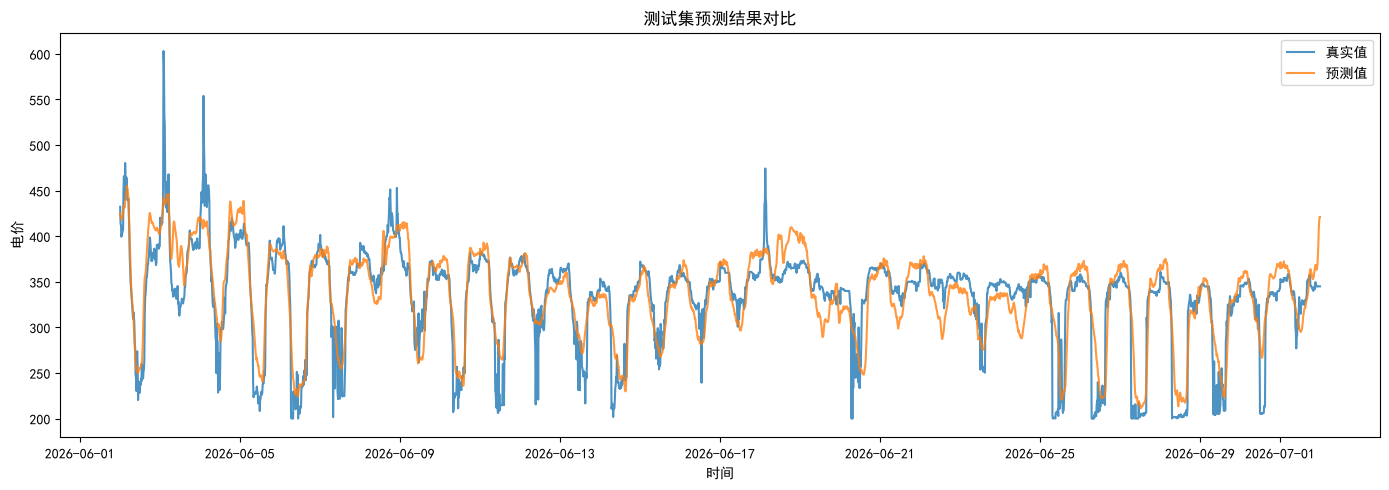

In [28]:
# 训练集预测可视化
test_timestamps = test_df["timestamp"].values
plt.figure(figsize=(14, 5))
plt.plot(test_timestamps, y_test, label="Actual", alpha=0.8)
plt.plot(test_timestamps, y_pred, label="Predicted", alpha=0.8)
plt.title("Test Set Prediction vs Actual")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

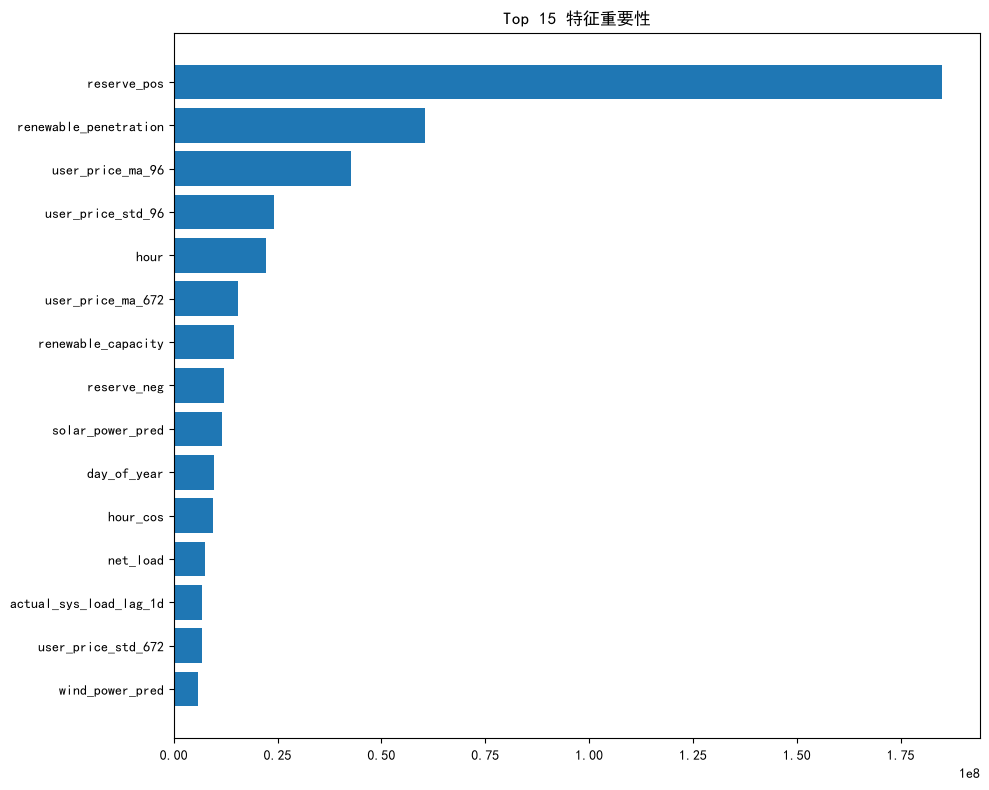

In [29]:
# 特征重要性
importance = model.get_feature_importance()
if importance is not None:
    plt.figure(figsize=(10, 8))
    top_n = 15
    imp_top = importance.sort_values("importance", ascending=True).tail(top_n)
    plt.barh(imp_top["feature"], imp_top["importance"])
    plt.title(f"Top {top_n} 特征重要性")
    plt.tight_layout()
    plt.show()

## 22. 预测指定日期

In [30]:
target_date = "2026-06-30"
target_dt = pd.to_datetime(target_date)
start_dt = target_dt - pd.Timedelta(days=30)
start_date = start_dt.strftime("%Y-%m-%d")
end_dt = target_dt + pd.Timedelta(days=1)
end_date = end_dt.strftime("%Y-%m-%d")

# 读取目标日期附近数据
pred_target_df = reader.read_target(start_date=start_date, end_date=end_date)

pred_feature_tables = {}
for name in feature_names:
    if name in CONFIG["data"]["sources"]:
        pred_feature_tables[name] = reader.read_table(name, start_date=start_date, end_date=end_date)

pred_actual_tables = {}
for name in ["actual_sys_load", "actual_wind", "actual_solar"]:
    if name in CONFIG["data"]["sources"]:
        pred_actual_tables[name] = reader.read_table(name, start_date=start_date, end_date=end_date)

if "actual_wind" in pred_actual_tables and "actual_solar" in pred_actual_tables:
    combined = pred_actual_tables["actual_wind"][["timestamp", "value"]].copy()
    combined = combined.merge(
        pred_actual_tables["actual_solar"][["timestamp", "value"]].rename(columns={"value": "solar"}),
        on="timestamp", how="outer"
    )
    combined["value"] = combined["value"].fillna(0) + combined["solar"].fillna(0)
    combined["field_name"] = "actual_wind_solar"
    pred_actual_tables["actual_wind_solar"] = combined[["timestamp", "value", "field_name"]]
    del pred_actual_tables["actual_wind"]
    del pred_actual_tables["actual_solar"]

pred_all_tables = {**pred_feature_tables, **pred_actual_tables}
pred_panel = adapter.build_panel(pred_all_tables, pred_target_df, align_to_target=False)
pred_panel = pred_panel.rename(columns={"target": "target"})
print("预测用面板数据形状:", pred_panel.shape)

预测用面板数据形状: (2977, 14)


In [31]:
# 构建预测特征
pred_features = feature_builder.build_all(pred_panel)
pred_features["target"] = pred_panel["target"].values

# 筛选目标日期
mask = pd.to_datetime(pred_features["timestamp"]).dt.date == target_dt.date()
pred_df = pred_features.loc[mask].copy()

X_pred = pred_df[feature_cols].values
y_pred_date = model.predict(X_pred)

result = pd.DataFrame({
    "timestamp": pd.to_datetime(pred_df["timestamp"]),
    "predicted_price": y_pred_date
})

pred_dir = Path(CONFIG["output"]["prediction_dir"])
pred_dir.mkdir(parents=True, exist_ok=True)
save_path = pred_dir / f"{target_date}_predictions.csv"
result.to_csv(save_path, index=False)
print(f"预测结果已保存至: {save_path}")
print(result.head(10))

预测结果已保存至: data\predictions\2026-06-30_predictions.csv
               timestamp  predicted_price
2880 2026-06-30 00:00:00       349.227861
2881 2026-06-30 00:15:00       357.038288
2882 2026-06-30 00:30:00       354.829280
2883 2026-06-30 00:45:00       355.809246
2884 2026-06-30 01:00:00       353.934496
2885 2026-06-30 01:15:00       355.420557
2886 2026-06-30 01:30:00       354.347781
2887 2026-06-30 01:45:00       355.602619
2888 2026-06-30 02:00:00       355.940347
2889 2026-06-30 02:15:00       361.177002


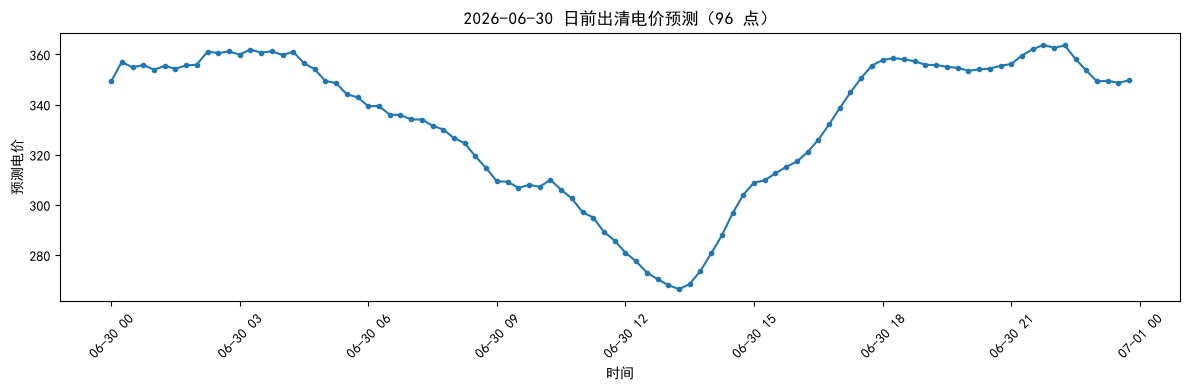

In [32]:
# 可视化单日预测曲线
plt.figure(figsize=(12, 4))
plt.plot(result["timestamp"], result["predicted_price"], marker="o", markersize=3)
plt.title(f"{target_date} 日前出清Price预测（96 点）")
plt.xlabel("Time")
plt.ylabel("预测Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 23. 评估单日预测（若实际值已公布）

2026-06-30 评估指标:
MAE: 21.10
RMSE: 30.81
MAPE: 8.15
sMAPE: 7.37
R2: 0.55
direction_accuracy: 51.06
spike_metrics:
  spike_capture_rate: 1.00
  spike_false_alarm: 0.00
  spike_miss_rate: 0.00
period_mape:
  0: 2.82
  1: 13.10
  2: 4.73


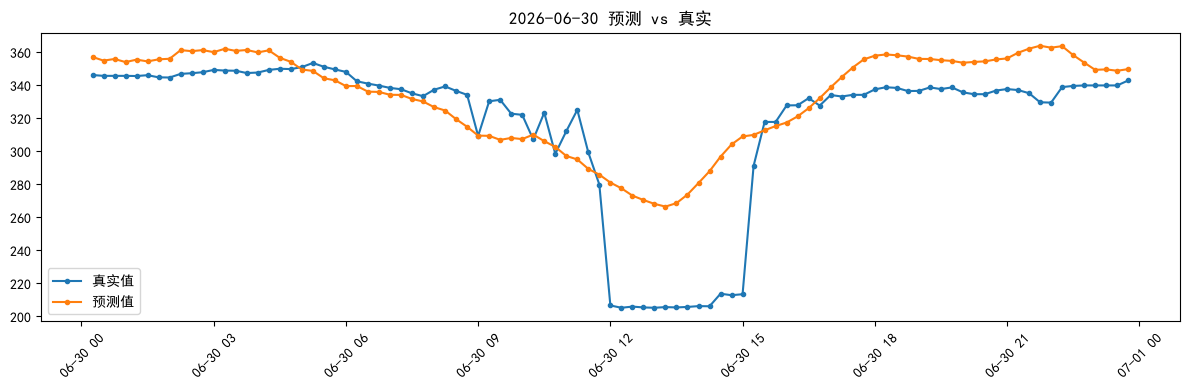

In [33]:
actual_series = pred_target_df.set_index("timestamp")["value"]
result["actual_price"] = result["timestamp"].map(actual_series)
valid = result.dropna(subset=["actual_price"])

if not valid.empty:
    calc = MetricsCalculator()
    y_true_date = valid["actual_price"].values
    y_pred_date_valid = valid["predicted_price"].values
    hours = valid["timestamp"].dt.hour
    periods = hours.apply(lambda h: 0 if h < 6 else (2 if 8 <= h < 11 or 17 <= h < 21 else 1)).values
    eval_metrics = calc.compute_all(y_true_date, y_pred_date_valid, periods=periods)
    print(f"{target_date} 评估指标:")
    for k, v in eval_metrics.items():
        if isinstance(v, dict):
            print(f"{k}:")
            for sk, sv in v.items():
                print(f"  {sk}: {sv:.2f}")
        else:
            print(f"{k}: {v:.2f}")

    plt.figure(figsize=(12, 4))
    plt.plot(valid["timestamp"], valid["actual_price"], label="Actual", marker="o", markersize=3)
    plt.plot(valid["timestamp"], valid["predicted_price"], label="Predicted", marker="o", markersize=3)
    plt.title(f"{target_date} Prediction vs Actual")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print(f"{target_date} 实际值尚未公布，无法评估")

## 24. Batch Evaluation of Multiple Days (30 Days)

Use `DailyRunner.evaluate_range` to predict, evaluate, save CSV, plot, and aggregate metrics for each day.


In [ ]:
from src.pipeline.daily_runner import DailyRunner

start_date = "2026-06-03"
end_date = "2026-07-02"

runner = DailyRunner(config_path="config/default.yaml")
range_result = runner.evaluate_range(start_date, end_date, model_path="models/wtlgbm.pkl")

print(f"Batch evaluation: {range_result['dates'][0]} ~ {range_result['dates'][-1]}")
print(f"Evaluated days: {range_result['n_evaluated']} / {len(range_result['dates'])}")
print("Aggregate metrics:")
for k, v in range_result['aggregate_metrics'].items():
    if isinstance(v, dict):
        print(f"  {k}:")
        for sk, sv in v.items():
            print(f"    {sk}: {sv:.4f}")
    else:
        print(f"  {k}: {v:.4f}")

summary_df = pd.read_csv(range_result['summary_csv'])
display(summary_df.head(10))
print(f"\nDaily CSV: {range_result['summary_csv']}")
print(f"Daily plots: reports/daily/")
